In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

Размер выборки: (200000, 11)


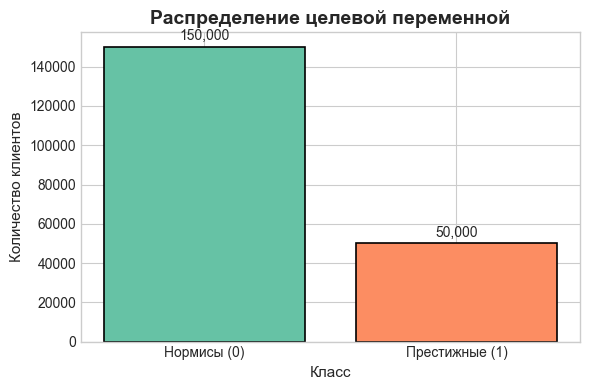

Диаграмма сохранена как 'class_distribution.png'
Порог 75-го перцентиля: 138,847.13 ₽
Train: (160000, 8), Test: (40000, 8)


In [27]:
df = pd.read_csv('ml_dataset.csv')
print(f"Размер выборки: {df.shape}")

threshold = df['total_spent'].quantile(0.75)
df['is_high_value'] = (df['total_spent'] > threshold).astype(int)

class_counts = df['is_high_value'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(['Нормисы (0)', 'Престижные (1)'], class_counts.values, 
               color=['#66c2a5', '#fc8d62'], edgecolor='black', linewidth=1.2)
plt.title('Распределение целевой переменной', fontsize=14, fontweight='bold')
plt.ylabel('Количество клиентов', fontsize=11)
plt.xlabel('Класс', fontsize=11)

for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Диаграмма сохранена как 'class_distribution.png'")
print(f"Порог 75-го перцентиля: {threshold:,.2f} ₽")

feature_cols = ['avg_check', 'max_order_amount', 'unique_products', 'unique_categories',
                'days_since_first_order', 'delivery_morning', 'delivery_day', 'delivery_evening']
X = df[feature_cols]
y = df['is_high_value']

if X.isnull().sum().any():
    X.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

In [28]:
param_grid = {
    'n_estimators': [50, 100, 200],       # Количество деревьев в лесу
    'max_depth': [None, 10, 20, 30],      # Максимальная глубина дерева
    'min_samples_split': [2, 5, 10]       # Минимальное число образцов для разделения узла
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1,         
    verbose=1
)

print(" Запуск GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\nЛучшие гиперпараметры: {grid_search.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

 Запуск GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучшие гиперпараметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Лучший F1-score на кросс-валидации: 0.9982



Classification Report (Test Set):
                precision    recall  f1-score   support

   Regular (0)       1.00      1.00      1.00     30000
High Value (1)       1.00      1.00      1.00     10000

      accuracy                           1.00     40000
     macro avg       1.00      1.00      1.00     40000
  weighted avg       1.00      1.00      1.00     40000

ROC-AUC Score: 0.9993



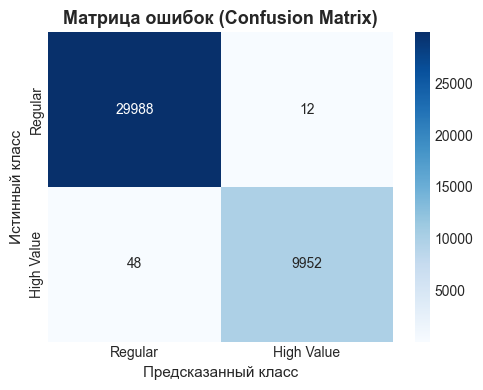

Сохранено: confusion_matrix.png


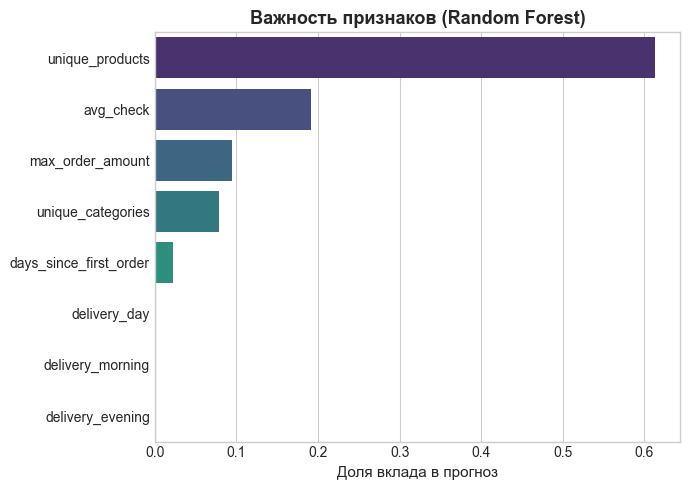

Сохранено: feature_importances.png


In [29]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Regular (0)', 'High Value (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Regular', 'High Value'], 
            yticklabels=['Regular', 'High Value'])
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=13, fontweight='bold')
plt.ylabel('Истинный класс', fontsize=11)
plt.xlabel('Предсказанный класс', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Сохранено: confusion_matrix.png")

importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(7, 5))
sns.barplot(x=importances[sorted_idx], y=[feature_cols[i] for i in sorted_idx], palette='viridis')
plt.title('Важность признаков (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Доля вклада в прогноз', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300, bbox_inches='tight')
plt.show()
print("Сохранено: feature_importances.png")

Исходный размер выборки: (1000000, 19)
Выборка сокращена до 200,000 записей для ускорения обучения.
Текущий размер выборки: (200000, 19)
Распределение статусов:
status
shipped       40242
new           40111
cancelled     39952
processing    39951
delivered     39744
Name: count, dtype: int64


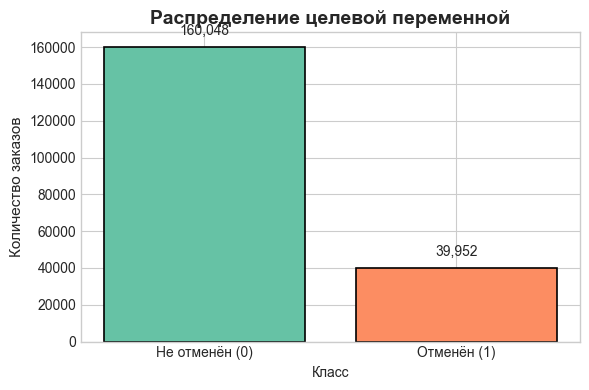


Процент отменённых заказов: 19.98%
Train: (160000, 16), Test: (40000, 16)
Доля отмен в train: 19.98%, в test: 19.98%


In [30]:
df = pd.read_csv('ml_dataset2.csv')
print(f"Исходный размер выборки: {df.shape}")

TARGET_SIZE = 200000
if len(df) > TARGET_SIZE:
    df = df.sample(n=TARGET_SIZE, random_state=42).reset_index(drop=True)
    print(f"Выборка сокращена до {TARGET_SIZE:,} записей для ускорения обучения.")
else:
    print(f"Исходная выборка меньше целевого размера. Используется весь датасет.")

print(f"Текущий размер выборки: {df.shape}")
print(f"Распределение статусов:\n{df['status'].value_counts()}")

df['is_cancelled'] = (df['status'] == 'cancelled').astype(int)

class_counts = df['is_cancelled'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(['Не отменён (0)', 'Отменён (1)'], class_counts.values, 
               color=['#66c2a5', '#fc8d62'], edgecolor='black', linewidth=1.2)
plt.title('Распределение целевой переменной', fontsize=14, fontweight='bold')
plt.ylabel('Количество заказов', fontsize=11)
plt.xlabel('Класс')
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('cancellation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

cancel_rate = df['is_cancelled'].mean() * 100
print(f"\nПроцент отменённых заказов: {cancel_rate:.2f}%")

feature_cols = ['loyalty_points', 'days_since_first_order', 'customer_total_orders', 
                'customer_avg_check', 'order_total_amount', 'items_count', 'total_kg',
                'avg_price_per_kg', 'unique_categories', 'has_premium_product', 
                'max_stock_kg', 'order_day_of_week', 'order_month',
                'delivery_morning', 'delivery_day', 'delivery_evening']

X = df[feature_cols].fillna(0)
y = df['is_cancelled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля отмен в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
F1-score на CV: 0.2642

Classification Report:
                precision    recall  f1-score   support

Не отменён (0)       0.80      0.60      0.68     32010
   Отменён (1)       0.20      0.41      0.27      7990

      accuracy                           0.56     40000
     macro avg       0.50      0.50      0.48     40000
  weighted avg       0.68      0.56      0.60     40000

 ROC-AUC: 0.5021


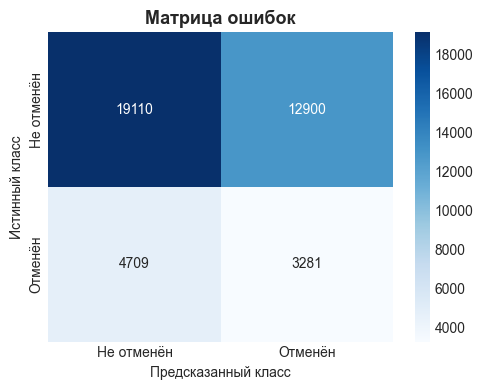

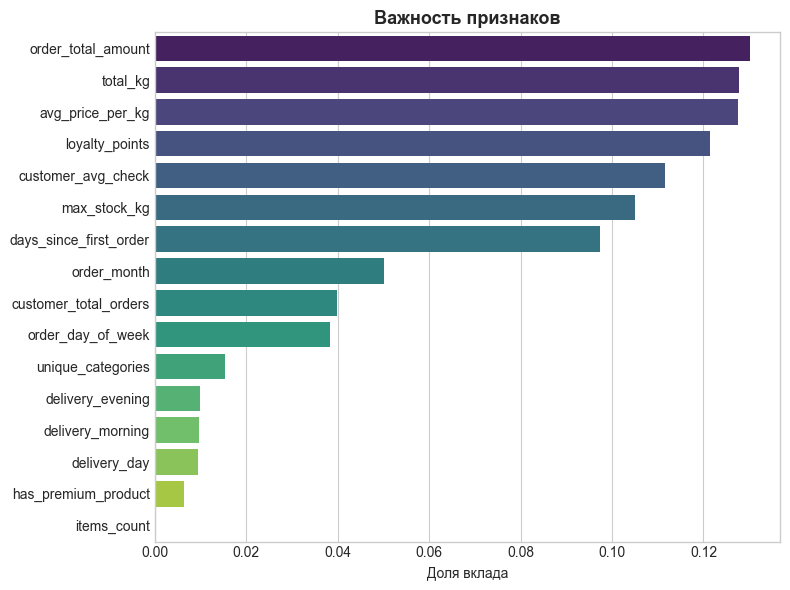

In [31]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"F1-score на CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Не отменён (0)', 'Отменён (1)']))
print(f" ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не отменён', 'Отменён'], 
            yticklabels=['Не отменён', 'Отменён'])
plt.title('Матрица ошибок', fontsize=13, fontweight='bold')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.savefig('cancellation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
sns.barplot(x=importances[sorted_idx], y=[feature_cols[i] for i in sorted_idx], palette='viridis')
plt.title('Важность признаков', fontsize=13, fontweight='bold')
plt.xlabel('Доля вклада')
plt.tight_layout()
plt.savefig('cancellation_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()